# LoRA ablation

## Goals:
- Understand how LoRA rank affects adaptation
- Compare attention-only LoRA with broader target modules
- Test learning-rate sensitivity
- Compare the best LoRA configuration with full fine-tuning

All experiments use:
- the same Dante dataset
- the same train/validation/test split
- the same batch size
- the same number of optimization steps
The test set is used only for the final comparison.

In [12]:
import gc
import json
import re
import math
import random
import pandas as pd
import numpy as np
import statistics
import time
import urllib.request
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, TaskType, get_peft_model



# Configuration
SEED = 42
MODEL_NAME = "LorenzoDeMattei/GePpeTto"
URL = "https://dmf.unicatt.it/~della/pythoncourse18/commedia.txt"
BLOCK_SIZE = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [13]:
# Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

In [14]:
# Data cleaning and tokenisation (same as original notebook)
canto_header = re.compile(r'^(Inferno|Purgatorio|Paradiso):\s*Canto\s+[IVXLCDM]+\s*$')

title_lines = {
    "LA DIVINA COMMEDIA",
    "di Dante Alighieri",
    "INFERNO",
    "PURGATORIO",
    "PARADISO",
}

def clean_editorial_lines(text):
    cleaned = []
    for line in text.splitlines():
        stripped = line.strip()
        if stripped in title_lines:
            continue
        if canto_header.match(stripped):
            continue
        cleaned.append(line)
    return '\n'.join(cleaned)

with urllib.request.urlopen(URL) as response:
    dante_text = clean_editorial_lines(response.read().decode('utf-8'))


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data = torch.tensor(tokenizer.encode(dante_text), dtype = torch.long)


# Data splitting

n1, n2 = int(0.9 * len(data)), int(0.95 * len(data))
train, val, test = data[:n1], data[n1:n2], data[n2:]

print(len(train), len(val), len(test))

156270 8682 8682


In [15]:
# Random training batches

def get_batch(batch_size, block_size=BLOCK_SIZE):
    max_start = len(train) - block_size

    ix = torch.randint(0, max_start +1 , (batch_size, ))
    x = torch.stack([train[i:i + block_size] for i in ix])

    return x

In [16]:
## Deterministic validation / test loss

@torch.no_grad()
def full_pass_loss(
    model,
    split,
    block_size=BLOCK_SIZE,
    chunk_batch=16
):
    """
    Compute deterministic causal-LM loss over the entire split.

    Windows are non-overlapping and the ragged tail is dropped.
    """

    model.eval()

    if split == "val":
        data_split = val
    elif split == "test":
        data_split = test
    else:
        raise ValueError("split must be 'val' or 'test'")

    n = (len(data_split) // block_size) * block_size

    windows = data_split[:n].view(-1, block_size)

    total_loss = 0.0
    total_windows = 0

    for i in range(0, len(windows), chunk_batch):

        xb = windows[i:i + chunk_batch].to(device)

        outputs = model(input_ids=xb,labels=xb)

        loss = outputs.loss

        batch_windows = xb.shape[0]

        total_loss += loss.item() * batch_windows
        total_windows += batch_windows

    return total_loss / total_windows


In [17]:
# ## Parameter counting

def count_parameters(model):

    total = sum(p.numel() for p in model.parameters())

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    percentage = 100 * trainable / total

    return total, trainable, percentage

In [18]:
# ## One experiment

# %%
def run(cfg, seed=42, eval_test=False):

    set_seed(seed)

    print(f"\nStarting: {cfg['name']}")
    print(f"seed={seed}")

    # --------------------------------------------------------
    # Load fresh copy of the pretrained model
    # --------------------------------------------------------

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME
    ).to(device)

    # --------------------------------------------------------
    # Apply LoRA if requested
    # --------------------------------------------------------

    if cfg["method"] == "lora":

        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,

            # Low-rank dimension
            r=cfg["r"],

            # Keeps alpha / r = 2 for rank experiments
            lora_alpha=cfg.get(
                "alpha",
                2 * cfg["r"]
            ),

            lora_dropout=cfg.get(
                "dropout",
                0.05
            ),

            # Which GPT-2 modules receive LoRA
            target_modules=cfg["targets"],

            # GPT-2 Conv1D stores dimensions transposed
            fan_in_fan_out=True,
        )

        model = get_peft_model(
            model,
            lora_config
        )

    elif cfg["method"] == "full":

        # Everything remains trainable.
        pass

    else:
        raise ValueError(f"Unknown method: {cfg['method']}")

    # --------------------------------------------------------
    # Parameter statistics
    # --------------------------------------------------------

    total_params, trainable_params, trainable_pct = (
        count_parameters(model))

    print(f"total parameters: {total_params:,}")

    print(f"trainable parameters: {trainable_params:,}")

    print(f"trainable percentage:  {trainable_pct:.4f}%")

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    params = [
        p for p in model.parameters()
        if p.requires_grad ]

    optimizer = torch.optim.AdamW(
        params,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"] )

    # --------------------------------------------------------
    # Step 0
    #
    # For LoRA, this should equal the original model's
    # zero-shot validation loss because the LoRA branch
    # initially contributes zero.
    # --------------------------------------------------------

    zero_shot_val = full_pass_loss(model,"val")

    curve = [{
        "step": 0,
        "train": float("nan"),
        "val": zero_shot_val
    }]

    recent_train_losses = []

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for step in range(cfg["steps"]):

        model.train()

        xb = get_batch(cfg["batch_size"]).to(device)

        outputs = model(input_ids=xb,labels=xb)

        loss = outputs.loss

        optimizer.zero_grad(set_to_none=True)

        loss.backward()

        optimizer.step()

        recent_train_losses.append(loss.item())

        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        if (step + 1) % cfg["eval_interval"] == 0:

            val_loss = full_pass_loss(model, "val")

            curve.append({
                "step": step + 1,
                "train": statistics.mean(recent_train_losses),
                "val": val_loss,})

            recent_train_losses = []

            print(
                f"step {step + 1:4d} | "
                f"train {curve[-1]['train']:.4f} | "
                f"val {val_loss:.4f}")

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    result = {
        "name": cfg["name"],
        "seed": seed,
        "trainable": trainable_params,
        "total_params": total_params,
        "trainable_pct": trainable_pct,
        "zero_shot_val": zero_shot_val,
        "final_val": curve[-1]["val"],
        "curve": curve,
    }

    # Test is deliberately optional.
    # We only call this for finalists.
    if eval_test:

        result["test"] = full_pass_loss(model,"test")

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del optimizer
    del params

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [19]:
# ## Experiment configuration

# %%
BASE = dict(
    method="lora",
    r=8,
    targets=["c_attn"],
    lr=2e-4,
    batch_size=8,
    steps=1000,
    eval_interval=100,
    weight_decay=0.01,
    dropout=0.05,
)


def make(name, **overrides):

    return {**BASE,"name": name,**overrides,}



In [20]:
# GPT-2:
# c_attn = Q/K/V attention projection
# c_proj = projection after attention + MLP output projection
# c_fc   = MLP expansion/up-projection
#
# Note: c_proj appears in both attention and MLP blocks.

ALL_LINEAR = ["c_attn","c_proj","c_fc",]

In [21]:
# ## Ablation experiments

# One factor at a time around the reference configuration.

EXPERIMENTS = [

    # Reference
    make("lora_r8_ref"),

    # Rank
    make("lora_r4",r=4),

    make("lora_r16",r=16),

    # Target modules
    make("lora_r8_all_linear", targets=ALL_LINEAR),

    # Learning rate
    make("lora_r8_lr1e-4",lr=1e-4),

    make("lora_r8_lr5e-4",lr=5e-4),

    # Full fine-tuning
    make("full_ft_lr5e-5", method="full", lr=5e-5, steps= 500, eval_interval = 50),
]

In [22]:
# Run ablation

results = []

for cfg in EXPERIMENTS:

    t0 = time.time()

    res = run(cfg, seed=SEED, eval_test=False)

    res["cfg"] = cfg

    res["minutes"] = (time.time() - t0) / 60

    results.append(res)

    # Save after every experiment
    # so a Colab interruption doesn't destroy everything.

    with open("ablation_results.json","w") as f:

        json.dump(results, f, indent=2)

    print(f"\nFINISHED: {cfg['name']}")

    print(f"trainable = {res['trainable']:,}")

    print(f"trainable % = {res['trainable_pct']:.3f}%")

    print(f"zero-shot val = {res['zero_shot_val']:.3f}")

    print(f"final val = {res['final_val']:.3f}")

    print(f"time = {res['minutes']:.3f} min")


Starting: lora_r8_ref
seed=42


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 109,177,344
trainable parameters: 294,912
trainable percentage:  0.2701%


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


step  100 | train 4.9903 | val 4.5121
step  200 | train 4.5035 | val 4.3540
step  300 | train 4.4049 | val 4.2802
step  400 | train 4.3380 | val 4.2402
step  500 | train 4.3195 | val 4.2076
step  600 | train 4.2877 | val 4.1800
step  700 | train 4.2494 | val 4.1807
step  800 | train 4.2381 | val 4.1575
step  900 | train 4.2278 | val 4.1467
step 1000 | train 4.1951 | val 4.1371

FINISHED: lora_r8_ref
trainable = 294,912
trainable % = 0.270%
zero-shot val = 6.301
final val = 4.137
time = 3.446 min

Starting: lora_r4
seed=42


...

total parameters: 109,177,344
trainable parameters: 294,912
trainable percentage:  0.2701%
step  100 | train 5.2279 | val 4.6944
step  200 | train 4.6515 | val 4.4772
step  300 | train 4.5175 | val 4.3898
step  400 | train 4.4427 | val 4.3357
step  500 | train 4.4183 | val 4.2975
step  600 | train 4.3825 | val 4.2621
step  700 | train 4.3457 | val 4.2449
step  800 | train 4.3306 | val 4.2279
step  900 | train 4.3187 | val 4.2112
step 1000 | train 4.2859 | val 4.1979

FINISHED: lora_r8_lr1e-4
trainable = 294,912
trainable % = 0.270%
zero-shot val = 6.301
final val = 4.198
time = 3.440 min

Starting: lora_r8_lr5e-4
seed=42


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 109,177,344
trainable parameters: 294,912
trainable percentage:  0.2701%
step  100 | train 4.7542 | val 4.3651
step  200 | train 4.3791 | val 4.2488
step  300 | train 4.2959 | val 4.1857
step  400 | train 4.2350 | val 4.1561
step  500 | train 4.2151 | val 4.1322
step  600 | train 4.1825 | val 4.1100
step  700 | train 4.1458 | val 4.1039
step  800 | train 4.1272 | val 4.0839
step  900 | train 4.1177 | val 4.0610
step 1000 | train 4.0819 | val 4.0554

FINISHED: lora_r8_lr5e-4
trainable = 294,912
trainable % = 0.270%
zero-shot val = 6.301
final val = 4.055
time = 3.431 min

Starting: full_ft_lr5e-5
seed=42


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 108,882,432
trainable parameters: 108,882,432
trainable percentage:  100.0000%
step   50 | train 4.4522 | val 4.2009
step  100 | train 4.0436 | val 4.0639
step  150 | train 3.8431 | val 4.0353
step  200 | train 3.7303 | val 4.0045
step  250 | train 3.5921 | val 3.9562
step  300 | train 3.5141 | val 3.9450
step  350 | train 3.4072 | val 3.9453
step  400 | train 3.2698 | val 3.9876
step  450 | train 3.1976 | val 3.9205
step  500 | train 3.1481 | val 4.0027

FINISHED: full_ft_lr5e-5
trainable = 108,882,432
trainable % = 100.000%
zero-shot val = 6.301
final val = 4.003
time = 2.571 min


In [23]:
#  Summary


summary = pd.DataFrame([

    {"name": r["name"],
     "method": r["cfg"]["method"],
     "rank": r["cfg"].get("r","-"),
     "targets": "+".join(r["cfg"].get("targets",[])) or "all weights",
     "lr": r["cfg"]["lr"],
     "trainable": r["trainable"],
     "trainable_%": round(r["trainable_pct"],4),
     "zero_shot_val": round(r["zero_shot_val"],4),
     "final_val": round(r["final_val"],4),
     "final_ppl": round(math.exp(r["final_val"]),1),
     "minutes": round(r["minutes"],1),}

    for r in results])


print(summary.to_string(index=False))


              name method  rank            targets      lr  trainable  trainable_%  zero_shot_val  final_val  final_ppl  minutes
       lora_r8_ref   lora     8             c_attn 0.00020     294912       0.2701         6.3006     4.1371       62.6      3.4
           lora_r4   lora     4             c_attn 0.00020     147456       0.1352         6.3006     4.1699       64.7      3.4
          lora_r16   lora    16             c_attn 0.00020     589824       0.5388         6.3006     4.0873       59.6      3.4
lora_r8_all_linear   lora     8 c_attn+c_proj+c_fc 0.00020    1179648       1.0718         6.3006     3.9485       51.9      3.9
    lora_r8_lr1e-4   lora     8             c_attn 0.00010     294912       0.2701         6.3006     4.1979       66.5      3.4
    lora_r8_lr5e-4   lora     8             c_attn 0.00050     294912       0.2701         6.3006     4.0554       57.7      3.4
    full_ft_lr5e-5   full     8             c_attn 0.00005  108882432     100.0000         6.3006

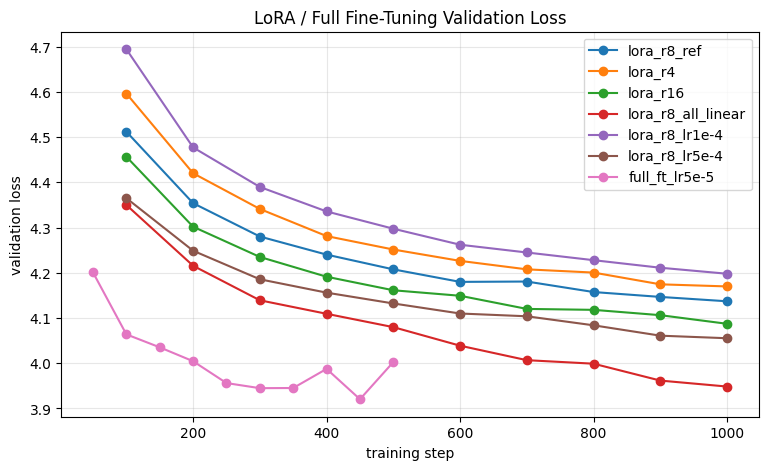

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [31]:
#  Validation curves


plt.figure(figsize=(9, 5))

for r in results:

    steps = [p["step"] for p in r["curve"] if p["step"] > 0]

    vals = [p["val"] for p in r["curve"] if p["step"] > 0]

    plt.plot(steps,vals,marker="o",label=r["name"])

plt.xlabel("training step")
plt.ylabel("validation loss")
plt.title("LoRA / Full Fine-Tuning Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.savefig("validation_curves.png", dpi=200, bbox_inches="tight")





In [25]:
#  Select best LoRA configuration
#
# Selection is based ONLY on validation loss.
# The test set has not been touched.


lora_results =[r for r in results if r["cfg"]["method"] == "lora"]

best_lora_result = min(lora_results, key=lambda r: r["final_val"])

best_lora = best_lora_result["cfg"]

full_cfg = next( c for c in EXPERIMENTS if c["method"] == "full")

print("Best LoRA configuration:")

print(best_lora)

Best LoRA configuration:
{'method': 'lora', 'r': 8, 'targets': ['c_attn', 'c_proj', 'c_fc'], 'lr': 0.0002, 'batch_size': 8, 'steps': 1000, 'eval_interval': 100, 'weight_decay': 0.01, 'dropout': 0.05, 'name': 'lora_r8_all_linear'}


In [26]:
# Final comparison
#
# Run the selected LoRA configuration and full fine-tuning
# using multiple seeds.
#
# Only NOW do we evaluate the test set.


FINAL_SEEDS = [1, 2, 3]

final_rows = []


for cfg in ( best_lora,full_cfg):

    for seed in FINAL_SEEDS:

        t0 = time.time()

        res = run(cfg, seed=seed, eval_test=True)

        row = {
            "name": cfg["name"],
            "seed": seed,
            "val": res["final_val"],
            "test": res["test"],
            "minutes": (time.time() - t0) / 60,}

        final_rows.append(row)

        print(row)




Starting: lora_r8_all_linear
seed=1


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 110,062,080
trainable parameters: 1,179,648
trainable percentage:  1.0718%
step  100 | train 4.7207 | val 4.3432
step  200 | train 4.3408 | val 4.2274
step  300 | train 4.2310 | val 4.1538
step  400 | train 4.1337 | val 4.1055
step  500 | train 4.0910 | val 4.0606
step  600 | train 4.0457 | val 4.0459
step  700 | train 3.9746 | val 4.0131
step  800 | train 3.9390 | val 4.0052
step  900 | train 3.8882 | val 3.9753
step 1000 | train 3.8734 | val 3.9688
{'name': 'lora_r8_all_linear', 'seed': 1, 'val': 3.968829340009547, 'test': 3.967825185007124, 'minutes': 3.8686911821365357}

Starting: lora_r8_all_linear
seed=2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 110,062,080
trainable parameters: 1,179,648
trainable percentage:  1.0718%
step  100 | train 4.7098 | val 4.3469
step  200 | train 4.3224 | val 4.2250
step  300 | train 4.2245 | val 4.1556
step  400 | train 4.1323 | val 4.1061
step  500 | train 4.0798 | val 4.0698
step  600 | train 4.0198 | val 4.0378
step  700 | train 3.9934 | val 4.0160
step  800 | train 3.9351 | val 4.0090
step  900 | train 3.9044 | val 3.9681
step 1000 | train 3.8652 | val 3.9487
{'name': 'lora_r8_all_linear', 'seed': 2, 'val': 3.9486522034033023, 'test': 3.9544018667135665, 'minutes': 3.8551066835721333}

Starting: lora_r8_all_linear
seed=3


...

total parameters: 108,882,432
trainable parameters: 108,882,432
trainable percentage:  100.0000%
step   50 | train 4.4439 | val 4.1986
step  100 | train 4.0178 | val 4.0851
step  150 | train 3.8554 | val 4.0205
step  200 | train 3.7280 | val 3.9955
step  250 | train 3.6113 | val 3.9925
step  300 | train 3.5225 | val 3.9653
step  350 | train 3.4027 | val 3.9398
step  400 | train 3.2824 | val 3.9412
step  450 | train 3.2121 | val 4.0040
step  500 | train 3.0939 | val 3.9831
{'name': 'full_ft_lr5e-5', 'seed': 1, 'val': 3.9830894185535946, 'test': 3.9787801415172974, 'minutes': 2.5748940825462343}

Starting: full_ft_lr5e-5
seed=2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 108,882,432
trainable parameters: 108,882,432
trainable percentage:  100.0000%
step   50 | train 4.4426 | val 4.2004
step  100 | train 4.0716 | val 4.0785
step  150 | train 3.8310 | val 4.0149
step  200 | train 3.7324 | val 3.9623
step  250 | train 3.5873 | val 3.9630
step  300 | train 3.4606 | val 3.9626
step  350 | train 3.3860 | val 3.9555
step  400 | train 3.3454 | val 3.9355
step  450 | train 3.1843 | val 3.9769
step  500 | train 3.1344 | val 3.9773
{'name': 'full_ft_lr5e-5', 'seed': 2, 'val': 3.977261934707414, 'test': 3.9712575264831087, 'minutes': 2.5758779724438985}

Starting: full_ft_lr5e-5
seed=3


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

total parameters: 108,882,432
trainable parameters: 108,882,432
trainable percentage:  100.0000%
step   50 | train 4.4551 | val 4.1915
step  100 | train 4.0233 | val 4.0646
step  150 | train 3.8857 | val 4.0236
step  200 | train 3.6893 | val 3.9877
step  250 | train 3.6268 | val 3.9564
step  300 | train 3.4827 | val 3.9780
step  350 | train 3.4451 | val 3.9634
step  400 | train 3.2819 | val 3.9661
step  450 | train 3.2182 | val 3.9997
step  500 | train 3.1652 | val 3.9992
{'name': 'full_ft_lr5e-5', 'seed': 3, 'val': 3.999214976581175, 'test': 3.9765719869243563, 'minutes': 2.571489417552948}


In [27]:
#  Final statistics


final = pd.DataFrame(final_rows)

print(final.to_string(index=False))


final_stats = (final.groupby("name")[["val", "test"]].agg(["mean", "std", "min", "max"]).round(4))


print(final_stats)


              name  seed      val     test  minutes
lora_r8_all_linear     1 3.968829 3.967825 3.868691
lora_r8_all_linear     2 3.948652 3.954402 3.855107
lora_r8_all_linear     3 3.954115 3.950837 3.866066
    full_ft_lr5e-5     1 3.983089 3.978780 2.574894
    full_ft_lr5e-5     2 3.977262 3.971258 2.575878
    full_ft_lr5e-5     3 3.999215 3.976572 2.571489
                       val                            test                  \
                      mean     std     min     max    mean     std     min   
name                                                                         
full_ft_lr5e-5      3.9865  0.0114  3.9773  3.9992  3.9755  0.0039  3.9713   
lora_r8_all_linear  3.9572  0.0104  3.9487  3.9688  3.9577  0.0090  3.9508   

                            
                       max  
name                        
full_ft_lr5e-5      3.9788  
lora_r8_all_linear  3.9678  


In [30]:
#  Save final results

final.to_csv("final_comparison.csv",index=False)

final_stats.to_csv("final_statistics.csv")

print("Saved:")

print("- ablation_results.json")

print("- final_comparison.csv")

print("- final_statistics.csv")


from google.colab import files

files.download("ablation_results.json")
files.download("final_comparison.csv")
files.download("final_statistics.csv")


Saved:
- ablation_results.json
- final_comparison.csv
- final_statistics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>